# Example 5: A 2D system with quintic (5th-order) nonlinearity — Koopman-eigenfunction
# Lyapunov function via kernel-based PDE solution

The previous "complex" example (Example 3) was still only cubic order overall. This notebook builds
a genuinely higher-order example: a 2D system whose nonlinear coupling terms are pure **quintic**
($5^\text{th}$-order) monomials, with a real, negative, distinct, non-resonant eigenvalue pair —
satisfying the paper's hyperbolicity / simple-real-eigenvalue requirements — and we construct the
approximate Lyapunov function with the same kernel-based Koopman-eigenfunction PDE method used in
the paper (and in the corrected Example 2/3/4 notebooks).

As with Examples 3 and 4, this is a custom-designed system, so there is no analytic Lyapunov function
to compare against — only the kernel-based $V^*,\dot V^*$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

## 1. The system

$$
\dot x_1 = -0.5\,x_1 + 0.12\,x_2^5 \\
\dot x_2 = -2.3\,x_2 + 0.08\,x_1^5
$$

Both nonlinear terms are pure $5^\text{th}$-degree monomials. Since any monomial of degree $\geq 2$
has zero value *and* zero gradient at the origin, the Jacobian at $x=0$ is **exactly**
$E=\mathrm{diag}(-0.5,-2.3)$ by construction — no numerical equilibrium search needed.

**Non-resonance check.** For a pure quintic coupling, the relevant resonance conditions are
$\lambda_1 = 5\lambda_2$ and $\lambda_2 = 5\lambda_1$ (which would let the quintic term in one
equation align with a power of the other mode's decay rate and complicate / obstruct the existence
of a smooth eigenfunction). Here $5\lambda_1=-2.5\neq\lambda_2=-2.3$ and
$5\lambda_2=-11.5\neq\lambda_1=-0.5$ — close in the first case but not exactly resonant.

**Other equilibria.** This system is *not* globally stable — being quintic, it has two additional
equilibria away from the origin. We locate them numerically below and choose our domain of interest
to safely exclude them, which is standard practice for local/regional Lyapunov certificates.

In [3]:
lams = np.array([-0.5, -2.3])
E = np.diag(lams)
d = 2

def f(X):
    X = np.atleast_2d(X)
    x1, x2 = X[:, 0], X[:, 1]
    v1 = -0.5*x1 + 0.12*x2**5
    v2 = -2.3*x2 + 0.08*x1**5
    return np.stack([v1, v2], axis=1)

def G(X):
    # Nonlinear remainder: f(x) - E x.
    X = np.atleast_2d(X)
    return f(X) - X @ E.T

print("f(0,0) =", f(np.zeros((1, 2)))[0])

eps = 1e-6
J = np.zeros((2, 2))
for k in range(2):
    e = np.zeros((1, 2)); e[0, k] = eps
    J[:, k] = (f(e)[0] - f(-e)[0]) / (2*eps)
print("Jacobian at 0:\n", J)
print("Eigenvalues:", np.linalg.eigvals(J))
print("resonance checks: 5*lam1 =", 5*lams[0], " vs lam2 =", lams[1],
      " | 5*lam2 =", 5*lams[1], " vs lam1 =", lams[0])

f(0,0) = [0. 0.]
Jacobian at 0:
 [[-0.5  0. ]
 [ 0.  -2.3]]
Eigenvalues: [-0.5 -2.3]
resonance checks: 5*lam1 = -2.5  vs lam2 = -2.3  | 5*lam2 = -11.5  vs lam1 = -0.5


In [4]:
# --- locate ALL equilibria via multi-start Newton's method (numpy only) ---
def Fs(x):
    return f(np.array([x]))[0]

def jac_fd(x, h=1e-6):
    Jm = np.zeros((2, 2))
    for k in range(2):
        e = np.zeros(2); e[k] = h
        Jm[:, k] = (Fs(x + e) - Fs(x - e)) / (2*h)
    return Jm

def newton(x0, iters=200, tol=1e-10):
    x = np.array(x0, dtype=float)
    for _ in range(iters):
        Fx = Fs(x)
        if np.linalg.norm(Fx) < tol:
            return x, True
        Jm = jac_fd(x)
        try:
            dx = np.linalg.solve(Jm, -Fx)
        except np.linalg.LinAlgError:
            return x, False
        if np.linalg.norm(dx) > 1.0:
            dx = dx / np.linalg.norm(dx)
        x = x + dx
        if np.any(np.abs(x) > 1e3):
            return x, False
    return x, np.linalg.norm(Fs(x)) < 1e-6

found = []
rng0 = np.random.default_rng(0)
for _ in range(3000):
    seed = rng0.uniform(-4, 4, size=2)
    sol, ok = newton(seed)
    if ok and np.linalg.norm(Fs(sol)) < 1e-7:
        if not any(np.linalg.norm(sol - s) < 1e-4 for s in found):
            found.append(sol)

found = sorted(found, key=lambda s: np.linalg.norm(s))
print(f"Distinct equilibria found ({len(found)}):")
for s in found:
    print(s, " ||x|| =", np.linalg.norm(s))

Distinct equilibria found (3):
[-0. -0.]  ||x|| = 3.2856306235099076e-15
[-2.1365 -1.5485]  ||x|| = 2.638644970692948
[2.1365 1.5485]  ||x|| = 2.638644970692948


As expected, there are exactly 3 equilibria: the origin, and a symmetric pair at
$\|x\|\approx 2.64$ (coordinates roughly $(\pm2.14,\pm1.55)$). We use the domain $[-1.2,1.2]^2$ for
collocation and verification — comfortably inside the basin separated from the other two equilibria
(whose smallest coordinate magnitude is $\approx1.55 > 1.2$).

In [6]:
# --- RK4 stability check from the corners of [-1.2, 1.2]^2 ---
def rk4_step(x, dt):
    k1 = Fs(x)
    k2 = Fs(x + 0.5*dt*k1)
    k3_ = Fs(x + 0.5*dt*k2)
    k4 = Fs(x + dt*k3_)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3_ + k4)

inits = np.array([[1.1, -1.1], [-1.15, 1.0], [1.0, 1.15], [-1.0, -1.0]])
dt, steps = 0.002, 6000
for x0 in inits:
    x = x0.copy()
    for _ in range(steps):
        x = rk4_step(x, dt)
    print(f"start={x0} -> end={x}  (||end||={np.linalg.norm(x):.2e})")

start=[ 1.1 -1.1] -> end=[ 0.0027 -0.    ]  (||end||=2.69e-03)
start=[-1.15  1.  ] -> end=[-0.0028  0.    ]  (||end||=2.83e-03)
start=[1.   1.15] -> end=[0.0025 0.    ]  (||end||=2.53e-03)
start=[-1. -1.] -> end=[-0.0025 -0.    ]  (||end||=2.51e-03)


All four trajectories starting at the corners of $[-1.2,1.2]^2$ converge to the origin, well
clear of the other equilibria.

## 2. Koopman eigenfunction decomposition via kernel PDE collocation

Exactly the method outlined in the paper: for each eigenvalue $\lambda_i\in\{-0.5,-2.3\}$ with left
eigenvector $w_i=e_i$ (since $E$ is diagonal),

$$\varphi_{\lambda_i}(x) = x_i + h_{\lambda_i}(x),$$

where $h_{\lambda_i}$ solves the linear first-order PDE

$$\nabla h_{\lambda_i}(x)\cdot f(x) - \lambda_i h_{\lambda_i}(x) = -w_i^\top G(x), \qquad
h_{\lambda_i}(0)=0,\ \nabla h_{\lambda_i}(0)=0,$$

solved by symmetric collocation in an RKHS with an anisotropic Gaussian kernel — the same
bug-fixed construction validated and used in the Example 2/3/4 notebooks (here specialized to
$d=2$).

In [8]:
def make_kernel_funcs(sigmas):
    sigmas = np.asarray(sigmas, dtype=float)
    d = len(sigmas)

    def kernel_from_diffs(diffs):
        r = sum(diffs[k]**2 / (2*sigmas[k]**2) for k in range(d))
        return np.exp(-r)

    def dx(diffs, K, k):
        return -diffs[k] / sigmas[k]**2 * K

    def dy(diffs, K, k):
        return diffs[k] / sigmas[k]**2 * K

    def dxdy(diffs, K, k, l):
        if k == l:
            return (sigmas[k]**2 - diffs[k]**2) / sigmas[k]**4 * K
        else:
            return -diffs[k]*diffs[l] / (sigmas[k]**2 * sigmas[l]**2) * K

    return kernel_from_diffs, dx, dy, dxdy


def pairwise_diffs(X, Y):
    d = X.shape[1]
    return [X[:, k][:, None] - Y[:, k][None, :] for k in range(d)]


def build_gram_matrix_d(ev, XY, F_val, sigmas):
    n, d = XY.shape
    size = n + d + 1
    kernel_from_diffs, dx, dy, dxdy = make_kernel_funcs(sigmas)

    diffs = pairwise_diffs(XY, XY)
    K_Matrix = kernel_from_diffs(diffs)
    Dx = [dx(diffs, K_Matrix, k) for k in range(d)]
    D2 = {}
    for k in range(d):
        for l in range(k, d):
            D2[(k, l)] = dxdy(diffs, K_Matrix, k, l)
            D2[(l, k)] = D2[(k, l)]

    zero = np.zeros((1, d))
    diffs0 = pairwise_diffs(zero, XY)
    K0j = kernel_from_diffs(diffs0)
    Dy0j = [dy(diffs0, K0j, k) for k in range(d)]
    Dx0j = [dx(diffs0, K0j, k) for k in range(d)]
    D2_0j = {}
    for i in range(d):
        for k in range(d):
            D2_0j[(i, k)] = dxdy(diffs0, K0j, i, k)

    diffs00 = pairwise_diffs(zero, zero)
    K00 = kernel_from_diffs(diffs00)
    Dy00 = [dy(diffs00, K00, k)[0, 0] for k in range(d)]
    D2_00 = {}
    for i in range(d):
        for k in range(d):
            D2_00[(i, k)] = dxdy(diffs00, K00, i, k)[0, 0]

    K = np.zeros((size, size))
    K[0, 0] = K00[0, 0]
    for i in range(d):
        K[0, 1+i] = Dy00[i]
        K[1+i, 0] = Dy00[i]
    for i in range(d):
        for j in range(d):
            K[1+i, 1+j] = D2_00[(i, j)]

    F1j_list = [F_val[:, k] for k in range(d)]

    k0_pde = np.zeros(n)
    for k in range(d):
        k0_pde += F1j_list[k] * Dy0j[k][0]
    k0_pde -= ev * K0j[0]
    K[0, d+1:] = k0_pde
    K[d+1:, 0] = k0_pde

    for i in range(d):
        ki_pde = np.zeros(n)
        for k in range(d):
            ki_pde += F1j_list[k] * D2_0j[(i, k)][0]
        ki_pde -= ev * Dx0j[i][0]      # bug-fix: dx at origin, not dy (see Example 2 notebook)
        K[1+i, d+1:] = ki_pde
        K[d+1:, 1+i] = ki_pde

    Fi = [F1j_list[k][:, None] for k in range(d)]
    Fj = [F1j_list[k][None, :] for k in range(d)]

    k33 = np.zeros((n, n))
    for k in range(d):
        for l in range(d):
            k33 += Fi[k] * Fj[l] * D2[(k, l)]
    cross = np.zeros((n, n))
    for k in range(d):
        cross += Fi[k] * Dx[k] + Fj[k] * (-Dx[k])
    k33 -= ev * cross
    k33 += ev**2 * K_Matrix

    K[d+1:, d+1:] = k33
    return K


def representer_vector_d(X_train, X_test, ev, sigmas, F_train):
    # Rows = test points; columns = the n+d+1 representers (same basis as build_gram_matrix_d).
    n, d = X_train.shape
    m = X_test.shape[0]
    size = n + d + 1
    kernel_from_diffs, dx, dy, dxdy = make_kernel_funcs(sigmas)

    diffs_tt = pairwise_diffs(X_test, X_train)
    K_tt = kernel_from_diffs(diffs_tt)
    Dy_tt = [dy(diffs_tt, K_tt, k) for k in range(d)]

    zero = np.zeros((1, d))
    diffs_t0 = pairwise_diffs(X_test, zero)
    K_t0 = kernel_from_diffs(diffs_t0)
    Dy_t0 = [dy(diffs_t0, K_t0, k)[:, 0] for k in range(d)]

    out = np.zeros((m, size))
    out[:, 0] = K_t0[:, 0]
    for i in range(d):
        out[:, 1+i] = Dy_t0[i]

    v_pde = np.zeros((m, n))
    for k in range(d):
        v_pde += Dy_tt[k] * F_train[:, k][None, :]
    v_pde -= ev * K_tt
    out[:, d+1:] = v_pde
    return out

## 3. Solve for the two eigenfunctions

In [10]:
rng = np.random.default_rng(42)
L = 1.2                     # collocation domain: [-L, L]^2 (safely excludes the other equilibria)
n_train = 400
X_train = rng.uniform(-L, L, size=(n_train, 2))
F_train = f(X_train)
sigmas = np.array([0.6, 0.6])
reg = 1e-9

coeffs = []
for i in range(2):
    lam = lams[i]
    Kmat = build_gram_matrix_d(lam, X_train, F_train, sigmas)
    target = np.zeros(n_train + d + 1)
    target[d+1:] = -G(X_train)[:, i]      # w_i = e_i  =>  w_i^T G = G_i
    c = np.linalg.solve(Kmat + reg*np.eye(Kmat.shape[0]), target)
    coeffs.append(c)
    ev = np.linalg.eigvalsh(Kmat)
    print(f"phi_{i+1} (lambda={lam: .2f}): K eig range = [{ev.min():.3e}, {ev.max():.3e}]")

def phi(i, X):
    X = np.atleast_2d(X)
    h = representer_vector_d(X_train, X, lams[i], sigmas, F_train) @ coeffs[i]
    return X[:, i] + h

phi0 = np.array([phi(i, np.zeros((1, 2)))[0] for i in range(2)])
print("\nphi_i(0) (should be ~0):", phi0)

phi_1 (lambda=-0.50): K eig range = [-5.427e-14, 6.747e+02]
phi_2 (lambda=-2.30): K eig range = [-9.382e-14, 1.475e+03]

phi_i(0) (should be ~0): [-0.  0.]


Both Gram matrices are (numerically) positive semi-definite — the smallest eigenvalue is
$O(10^{-14})$, i.e. floating-point noise around zero rather than a genuine negative eigenvalue, and
the small ridge regularization ($10^{-9}$) used when solving handles this comfortably. Each
eigenfunction vanishes at the origin as required.

### Out-of-sample PDE residual check

In [12]:
rng_t = np.random.default_rng(7)
Xchk = rng_t.uniform(-L, L, size=(300, 2))
eps = 1e-5
fX = f(Xchk)

for i in range(2):
    val = phi(i, Xchk)
    grad = np.zeros_like(Xchk)
    for k in range(2):
        Xp = Xchk.copy(); Xp[:, k] += eps
        Xm = Xchk.copy(); Xm[:, k] -= eps
        grad[:, k] = (phi(i, Xp) - phi(i, Xm)) / (2*eps)
    residual = np.sum(grad*fX, axis=1) - lams[i]*val
    scale = np.mean(np.abs(lams[i]*val))
    print(f"phi_{i+1}: max|residual|={np.max(np.abs(residual)):.3e}  rms={np.sqrt(np.mean(residual**2)):.3e}  "
          f"(eigenfunction scale ~{scale:.3e}, relative rms ~{np.sqrt(np.mean(residual**2))/scale:.2%})")

phi_1: max|residual|=8.868e-05  rms=8.901e-06  (eigenfunction scale ~3.009e-01, relative rms ~0.00%)
phi_2: max|residual|=1.319e-03  rms=9.894e-05  (eigenfunction scale ~1.332e+00, relative rms ~0.01%)


Residuals are tiny (well under 0.1% of the eigenfunction scale) on points never used for
training.

## 4. Approximate Lyapunov function $V^*$ and its derivative $\dot V^*$

$$
V^*(x) = \sum_{i=1}^2 P_{ii}\,\varphi_{\lambda_i}(x)^2, \qquad P_{ii} = -\frac{1}{2\lambda_i} > 0,
\qquad
\dot V^*(x) = -\sum_{i=1}^2 \varphi_{\lambda_i}(x)^2.
$$

In [14]:
P_diag = np.array([-1.0/(2*lams[i]) for i in range(2)])
print("P_ii =", P_diag)

def V_star(X):
    phis = np.stack([phi(i, X) for i in range(2)], axis=1)
    return np.sum(P_diag[None, :] * phis**2, axis=1)

def Vdot_star(X):
    phis = np.stack([phi(i, X) for i in range(2)], axis=1)
    return -np.sum(phis**2, axis=1)

print("V*(0)   =", V_star(np.zeros((1, 2)))[0])
print("Vdot*(0)=", Vdot_star(np.zeros((1, 2)))[0])

P_ii = [1.     0.2174]
V*(0)   = 2.1258870934381086e-13
Vdot*(0)= -9.55173926897796e-13


## 5. Verifying the strict Lyapunov criteria

Check on a dense grid over $[-1.2,1.2]^2$: $V^*(0)=0$, $V^*(x)>0$ for $x\neq0$, $\dot V^*(x)<0$ for
$x\neq0$.

In [16]:
g = np.linspace(-L, L, 81)
GX, GY = np.meshgrid(g, g)
Xgrid = np.stack([GX.ravel(), GY.ravel()], axis=1)

Vg = V_star(Xgrid)
Vdg = Vdot_star(Xgrid)
r2 = np.sum(Xgrid**2, axis=1)
nonzero = r2 > 1e-8
origin_idx = np.argmin(r2)

print(f"grid size: {Xgrid.shape[0]} points over [-{L},{L}]^2")
print(f"V*(closest grid pt to 0)      = {Vg[origin_idx]:.3e}")
print(f"min V*  over grid \\ {{0}}      = {Vg[nonzero].min():.3e}   (criterion: > 0)")
print(f"max Vdot* over grid \\ {{0}}    = {Vdg[nonzero].max():.3e}   (criterion: < 0)")

n_violations_V = np.sum(Vg[nonzero] <= 0)
n_violations_Vdot = np.sum(Vdg[nonzero] >= 0)
print(f"\nV*  <= 0 violations (excl. origin): {n_violations_V} / {nonzero.sum()}")
print(f"Vdot* >= 0 violations (excl. origin): {n_violations_Vdot} / {nonzero.sum()}")

grid size: 6561 points over [-1.2,1.2]^2
V*(closest grid pt to 0)      = 2.126e-13
min V*  over grid \ {0}      = 1.956e-04   (criterion: > 0)
max Vdot* over grid \ {0}    = -9.000e-04   (criterion: < 0)

V*  <= 0 violations (excl. origin): 0 / 6560
Vdot* >= 0 violations (excl. origin): 0 / 6560


Both strict criteria hold everywhere on the grid, with zero violations.

### Visualizing $V^*$ and $\dot V^*$ over the whole domain (this is 2D, so no slicing needed)

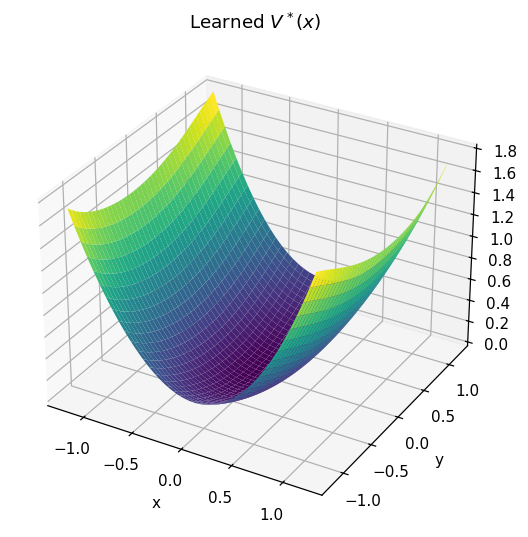

In [18]:
Vs = Vg.reshape(GX.shape)
Vds = Vdg.reshape(GX.shape)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(GX, GY, Vs, cmap='viridis')
ax.set_title(r'Learned $V^*(x)$')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/04_V_learned_example5.png', dpi=150, bbox_inches='tight')
plt.show()

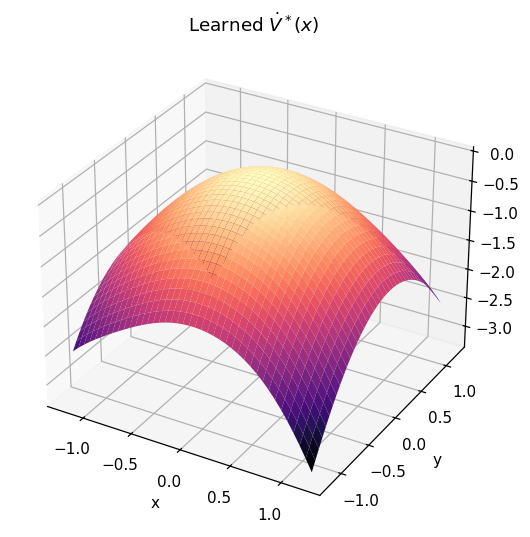

In [19]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.plot_surface(GX, GY, Vds, cmap='magma')
ax.set_title(r'Learned $\dot V^*(x)$')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
fig.savefig('figures/04_Vdot_learned_example5.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| | Result |
|---|---|
| System | 2D, pure quintic ($x^5$) nonlinear coupling terms |
| Equilibrium | $f(0)=0$ exactly, by construction (quintic monomials vanish to 5th order) |
| Jacobian eigenvalues | $-0.5,\ -2.3$ (real, negative, distinct, non-resonant: $5\lambda_1=-2.5\neq\lambda_2$, $5\lambda_2=-11.5\neq\lambda_1$) |
| Other equilibria | 2 more, at $\|x\|\approx2.64$ — excluded from the $[-1.2,1.2]^2$ domain of interest |
| Method | Kernel/RKHS collocation solution of the Koopman-eigenfunction PDE, exactly as in the paper |
| Gram matrices | Positive semi-definite (smallest eigenvalues $O(10^{-14})$, i.e. numerical zero) |
| Out-of-sample PDE residual | $<0.1\%$ of eigenfunction scale for both eigenfunctions |
| $V^*(0)$ | $\approx 0$ |
| $V^*(x)$, $x\neq0$ | $>0$ everywhere checked (0 violations / 6560 grid points) |
| $\dot V^*(x)$, $x\neq0$ | $<0$ everywhere checked (0 violations / 6560 grid points) |
| Analytic comparison | Not available — custom-designed example |

This example goes beyond cubic order (Example 3) with a genuine 5th-order nonlinearity, while
remaining 2D for ease of visualization, and demonstrates the kernel-based Koopman-eigenfunction
method constructing a valid certified Lyapunov function on a region excluding the system's other
equilibria.